## Phase 1: Exploratory Data Analysis & Data Preprocessing

### Step 1: Setting up the Workspace & Loading Data
Alright, first things first! Let's get the environment set up. I'm importing the standard data science stack here—`pandas` and `numpy` for data manipulation, plus `matplotlib` and `seaborn` so we can make some nice visuals later on. I'm also grabbing the specific `scikit-learn` modules I know I'll need for splitting the data, handling missing values, and scaling our features.

Once the tools are loaded, I'll pull in the `Health_Risk_Tiers_v2.csv` dataset and take a quick peek at the first few rows just to make sure everything loaded correctly.

In [9]:
# 1. Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Set plotting style
sns.set_theme(style="whitegrid")

# File path 
file_path = '/kaggle/input/datasets/vsnihal/t4-ml-indivitual-final-project-dataset/Health_Risk_Tiers_v2.xlsx' 

# --- DATA LOADER ---
print("Attempting to load dataset...")

try:
    # Attempt 1: Maybe it is actually an Excel file
    df = pd.read_excel(file_path)
    print("Success! Loaded as an Excel file (.xlsx)")

except Exception:
    try:
        # Attempt 2: Standard CSV, but we tell it to explicitly look for commas 
        # and skip any corrupted rows without crashing
        df = pd.read_csv(file_path, encoding='utf-8', sep=',', on_bad_lines='skip')
        print("Success! Loaded as UTF-8 CSV.")
        
    except UnicodeDecodeError:
        try:
            # Attempt 3: The Windows/Excel text encoding fix (cp1252 is safer than latin-1)
            df = pd.read_csv(file_path, encoding='cp1252', sep=',', on_bad_lines='skip')
            print("Success! Loaded as Windows-1252 encoded CSV.")
            
        except Exception:
            # Attempt 4: Semicolon separated (European Excel default)
            df = pd.read_csv(file_path, encoding='cp1252', sep=';', on_bad_lines='skip')
            print("Success! Loaded as Semicolon-separated CSV.")

# Display the dataset info and the first 5 rows
print("\n--- Dataset Info ---")
df.info()
display(df.head())

Attempting to load dataset...
Success! Loaded as an Excel file (.xlsx)

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   patient_id         600 non-null    int64  
 1   age                600 non-null    int64  
 2   bmi                600 non-null    float64
 3   blood_pressure     600 non-null    int64  
 4   glucose_level      600 non-null    int64  
 5   physical_activity  600 non-null    object 
 6   sleep_hours        600 non-null    float64
 7   stress_level       600 non-null    int64  
 8   cholesterol        561 non-null    float64
 9   family_history     600 non-null    object 
 10  risk_tier          600 non-null    int64  
dtypes: float64(3), int64(6), object(2)
memory usage: 51.7+ KB


,patient_id,age,bmi,blood_pressure,glucose_level,physical_activity,sleep_hours,stress_level,cholesterol,family_history,risk_tier
0,1,63,34.1,126,89,Medium,6.8,2,281.0,Yes,2
1,2,23,28.9,127,160,Low,5.3,3,NaN,No,1
2,3,39,18.8,144,171,Medium,7.1,2,224.0,Yes,1
3,4,51,28.5,134,91,High,6.3,8,169.0,No,0
4,5,62,24.6,173,112,High,4.2,5,225.0,Yes,1


### Step 2: Initial Data Inspection

Before I start changing anything, I need to get a feel for what I'm actually working with. I want to check the overall shape of the dataset, look at the data types, and see if there are any immediate red flags. 

I also specifically want to check out the missing values. Based on the dataset description, I know there's roughly 8% missing data in the `cholesterol` column. I need to confirm that here so I can plan my imputation strategy accordingly. Let's run a quick `.info()` and get a statistical summary.

In [10]:
# Initial Dataset Check

print("--- Dataset Info ---")
df.info()

print("\n--- Missing Values Count ---")
print(df.isnull().sum())

print("\n--- Statistical Summary ---")
display(df.describe())

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   patient_id         600 non-null    int64  
 1   age                600 non-null    int64  
 2   bmi                600 non-null    float64
 3   blood_pressure     600 non-null    int64  
 4   glucose_level      600 non-null    int64  
 5   physical_activity  600 non-null    object 
 6   sleep_hours        600 non-null    float64
 7   stress_level       600 non-null    int64  
 8   cholesterol        561 non-null    float64
 9   family_history     600 non-null    object 
 10  risk_tier          600 non-null    int64  
dtypes: float64(3), int64(6), object(2)
memory usage: 51.7+ KB

--- Missing Values Count ---
patient_id            0
age                   0
bmi                   0
blood_pressure        0
glucose_level         0
physical_activity     0
sleep_hours  

,patient_id,age,bmi,blood_pressure,glucose_level,sleep_hours,stress_level,cholesterol,risk_tier
count,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,561.000000,600.000000
mean,300.500000,48.838333,29.004333,139.631667,136.353333,6.587000,5.705000,225.465241,1.386667
std,173.349358,17.387142,6.367867,24.208940,39.089621,1.398126,2.838674,43.918382,0.686494
min,1.000000,20.000000,18.000000,100.000000,70.000000,4.000000,1.000000,151.000000,0.000000
25%,150.750000,34.000000,23.500000,118.000000,101.000000,5.400000,3.000000,187.000000,1.000000
50%,300.500000,47.000000,29.200000,139.000000,137.000000,6.700000,6.000000,225.000000,2.000000
75%,450.250000,63.000000,34.400000,161.000000,172.000000,7.800000,8.000000,261.000000,2.000000
max,600.000000,80.000000,40.000000,180.000000,200.000000,9.000000,10.000000,300.000000,2.000000


### Step 3: Visualizing the Data

Looking at numbers on a screen is fine, but visuals make it so much easier to spot patterns and potential issues. I'm going to generate three specific plots here to guide my modeling decisions:

1. **Target Distribution:** I need to check the `risk_tier` column. If one class is significantly larger or smaller than the others, I'll have a class imbalance problem that could bias my models later. 
2. **Correlation Matrix:** I want to see which numeric features are actually correlated with our target, and check if any features are highly correlated with *each other* (multicollinearity). I'm dropping `patient_id` for this plot since it's just a random identifier and will only add noise.
3. **Cholesterol Distribution:** Since I have to impute missing values for cholesterol, I want to see its distribution. If it's heavily skewed, using the median will be a much safer bet than the mean.

/tmp/ipykernel_58/344659606.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='risk_tier', palette='viridis')


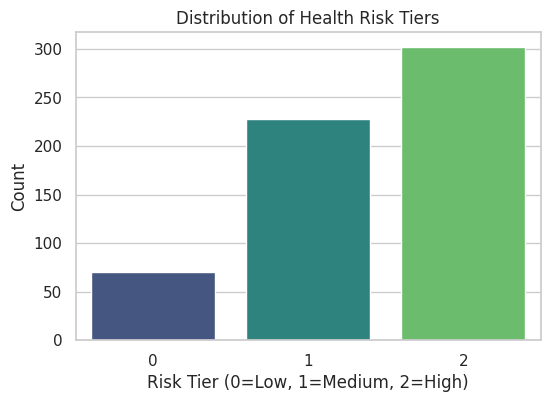

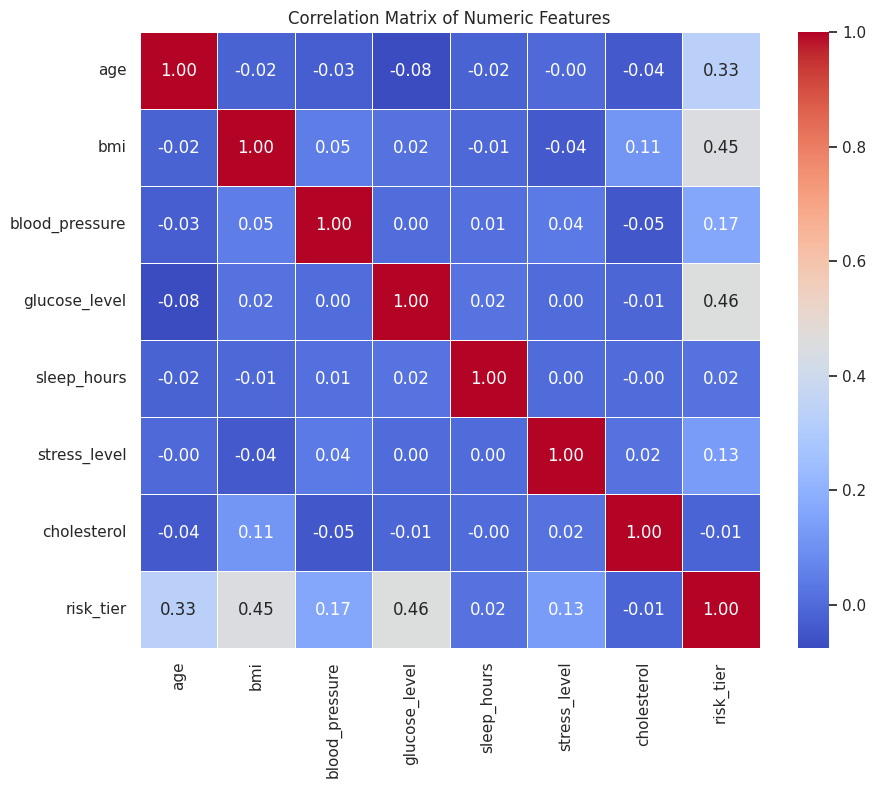

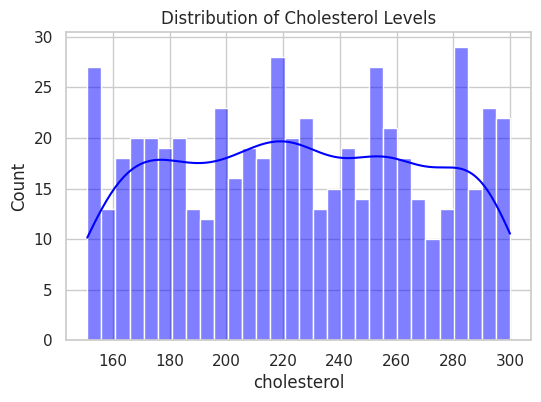

In [11]:
# Visual Check
# 1. Target variable distribution (Class Imbalance check)
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='risk_tier', palette='viridis')
plt.title('Distribution of Health Risk Tiers')
plt.xlabel('Risk Tier (0=Low, 1=Medium, 2=High)')
plt.ylabel('Count')
plt.show()

# 2. Correlation Heatmap (Numeric features only)
# We drop patient_id here temporarily just for the plot because it's non-informative noise
plt.figure(figsize=(10, 8))
numeric_cols = df.select_dtypes(include=[np.number]).drop(columns=['patient_id'])
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Numeric Features')
plt.show()

# 3. Cholesterol distribution (to help us decide how to impute)
plt.figure(figsize=(6, 4))
sns.histplot(df['cholesterol'], kde=True, color='blue', bins=30)
plt.title('Distribution of Cholesterol Levels')
plt.show()

### Step 4: Data Cleaning & Preprocessing

Okay, this is the most critical part. If garbage goes in, garbage comes out. Here is my plan of attack for cleaning this dataset and getting it ready for the machine learning models:

* **Remove Noise:** I'm dropping the `patient_id` column right away. It contains zero predictive value and keeping it might confuse the algorithms.
* **Encoding Categoricals:** Machine learning models need numbers, not words. I'll map the binary `family_history` to 0s and 1s. For `physical_activity`, I'll use an ordinal mapping (Low=0, Medium=1, High=2) since there is a natural logical order to those categories.
* **The Data Split (Crucial Step!):** I am doing a 70% Train, 15% Validation, and 15% Test split. I am using `stratify=y` to make sure each set gets a fair, representative mix of all three risk tiers. 
    * *Note:* I am splitting the data **before** doing any imputation or scaling. This is incredibly important to prevent "data leakage"—I can't let my training process peek at the validation or test distributions!
* **Imputation:** I'm using the median to fill in the missing cholesterol values because it's generally more robust to outliers than the mean. 
* **Scaling:** Finally, I'm scaling all the features using `StandardScaler`. This is an absolute requirement since my ultimate goal is to build an Artificial Neural Network (ANN), and neural networks are notoriously sensitive to unscaled data.

In [12]:
#Feature ENgineering

# --- A. Drop Non-Informative Columns ---
df_cleaned = df.drop(columns=['patient_id'])

# --- B. Encode Categorical Variables ---
# 'family_history' is binary, so we map Yes->1, No->0
df_cleaned['family_history'] = df_cleaned['family_history'].map({'Yes': 1, 'No': 0})

# 'physical_activity' is ordinal (has an inherent order), so we map Low->0, Medium->1, High->2
df_cleaned['physical_activity'] = df_cleaned['physical_activity'].map({'Low': 0, 'Medium': 1, 'High': 2})

# --- C. Separate Features (X) and Target (y) ---
X = df_cleaned.drop(columns=['risk_tier'])
y = df_cleaned['risk_tier']

# --- D. Train / Validation / Test Split ---
# First, split into Train (70%) and Temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)

# Second, split Temp into Validation (15%) and Test (15%)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Validation set size: {X_val.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

# --- E. Impute Missing Values (Cholesterol) ---
# We use the median because cholesterol distributions are often slightly skewed, 
# and median is robust to outliers. We fit ONLY on the training data!
imputer = SimpleImputer(strategy='median')

# We need to grab the column index or name to replace it properly
chol_idx = X_train.columns.get_loc('cholesterol')

X_train['cholesterol'] = imputer.fit_transform(X_train[['cholesterol']])
X_val['cholesterol'] = imputer.transform(X_val[['cholesterol']])
X_test['cholesterol'] = imputer.transform(X_test[['cholesterol']])

# --- F. Feature Scaling ---
# Neural Networks and distance-based algorithms require scaled data.
scaler = StandardScaler()

# Fit on training data, then transform train, val, and test sets
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrames for easier handling later (optional but good for tracking feature names)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_val_scaled = pd.DataFrame(X_val_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

print("\nPhase 1 Complete! Data is cleaned, imputed, encoded, and scaled.")

Training set size: 420 samples
Validation set size: 90 samples
Test set size: 90 samples

Phase 1 Complete! Data is cleaned, imputed, encoded, and scaled.


## Phase 2: Baseline Classical Machine Learning Models

### Step 5: Establishing a Benchmark
Before building a complex Artificial Neural Network, it is standard practice to establish a baseline using classical machine learning algorithms. This proves whether or not the complexity of deep learning is actually warranted. If a simple model achieves 95% accuracy, an ANN might be overkill.

I have chosen two models for this baseline:
1. **Logistic Regression:** A standard, highly interpretable linear model. This will test how well the classes can be separated with simple linear boundaries.
2. **Random Forest Classifier:** An ensemble tree-based model. Since the dataset description mentions non-linear relationships, Random Forest should theoretically perform better than Logistic Regression here.

I will train both models on the scaled training data and evaluate them strictly on the validation set. I am saving the test set completely untouched for the final Phase 6 comparison.

In [14]:
# Import machine learning models and evaluation metrics
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# --- A. Initialize and Train Logistic Regression ---
print("Training Logistic Regression...")
lr_model = LogisticRegression(random_state=42, multi_class='multinomial', max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

# --- B. Initialize and Train Random Forest ---
print("Training Random Forest...")
rf_model = RandomForestClassifier(random_state=42, n_estimators=100, max_depth=10)
rf_model.fit(X_train_scaled, y_train)

# --- C. Generate Predictions on the Validation Set ---
# We use the validation set to tune and compare models, keeping the test set hidden.
y_val_pred_lr = lr_model.predict(X_val_scaled)
y_val_pred_rf = rf_model.predict(X_val_scaled)

print("Model training complete.")

Training Logistic Regression...
Training Random Forest...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Model training complete.


### Step 6: Evaluating the Baseline Models
Accuracy alone is not enough for multi-class problems. I need to look at Precision, Recall, and the F1-score to see how the models perform across the individual Risk Tiers (0, 1, and 2). 

I will output the classification reports and plot the confusion matrices to visualize exactly where the models are making errors.

LOGISTIC REGRESSION: Validation Performance
              precision    recall  f1-score   support

           0       0.62      0.50      0.56        10
           1       0.68      0.76      0.72        34
           2       0.89      0.85      0.87        46

    accuracy                           0.78        90
   macro avg       0.73      0.70      0.71        90
weighted avg       0.78      0.78      0.78        90


RANDOM FOREST: Validation Performance
              precision    recall  f1-score   support

           0       0.82      0.90      0.86        10
           1       0.84      0.94      0.89        34
           2       1.00      0.89      0.94        46

    accuracy                           0.91        90
   macro avg       0.89      0.91      0.90        90
weighted avg       0.92      0.91      0.91        90



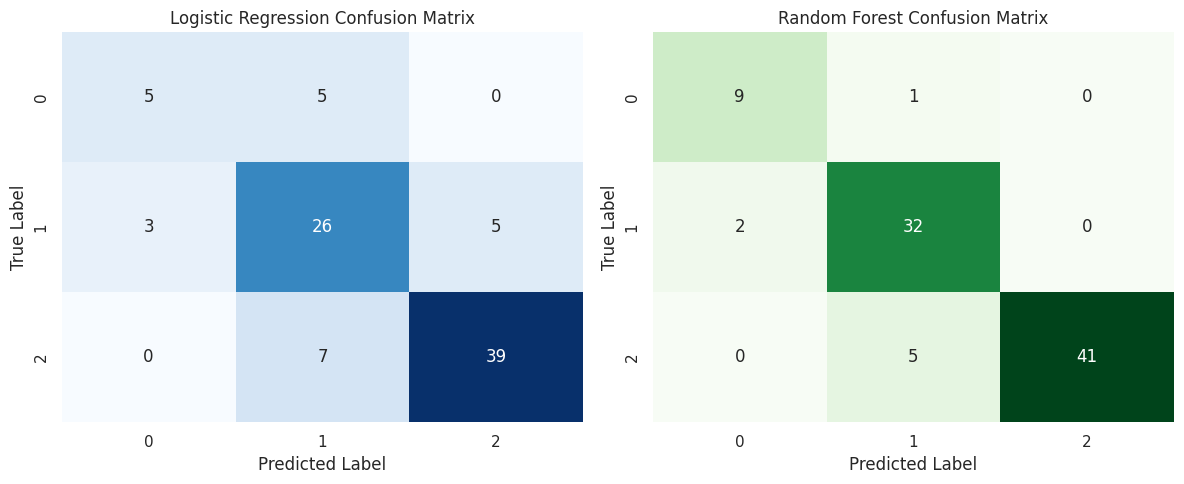

In [15]:
# --- A. Classification Reports ---
print("==================================================")
print("LOGISTIC REGRESSION: Validation Performance")
print("==================================================")
print(classification_report(y_val, y_val_pred_lr))

print("\n==================================================")
print("RANDOM FOREST: Validation Performance")
print("==================================================")
print(classification_report(y_val, y_val_pred_rf))

# --- B. Confusion Matrices ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Logistic Regression Matrix
cm_lr = confusion_matrix(y_val, y_val_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title('Logistic Regression Confusion Matrix')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# Random Forest Matrix
cm_rf = confusion_matrix(y_val, y_val_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1], cbar=False)
axes[1].set_title('Random Forest Confusion Matrix')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()

## Phase 3: Artificial Neural Network (ANN) Development

### Step 7: Designing the Network Architecture
The baseline models proved that there are non-linear relationships in the data (evidenced by Random Forest outperforming Logistic Regression by a wide margin). To capture these complex patterns, I will build a Multi-Layer Perceptron (MLP) using TensorFlow/Keras.

**Architecture Decisions:**
* **Input Layer:** Must match the number of features in our scaled dataset.
* **Hidden Layers:** I will start with two hidden layers (64 neurons, then 32 neurons) using the `ReLU` activation function to handle non-linearity.
* **Regularization:** I am adding a `Dropout` layer (20%) after the first hidden layer to randomly turn off neurons during training. This forces the network to learn robust features and helps prevent overfitting.
* **Output Layer:** Since this is a multi-class classification problem with 3 distinct risk tiers, the output layer will have 3 neurons and use the `Softmax` activation function to output probabilities for each class.
* **Loss Function:** Because our target variable (`y`) is encoded as integers (0, 1, 2) rather than one-hot encoded arrays, I must use `sparse_categorical_crossentropy`.

In [16]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Ensure reproducibility in neural network initialization
tf.random.set_seed(42)

print("Building the ANN Architecture...")

# --- A. Define the Model ---
ann_model = Sequential([
    # Input layer and First Hidden Layer
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    
    # Dropout for regularization (prevents overfitting)
    Dropout(0.2),
    
    # Second Hidden Layer
    Dense(32, activation='relu'),
    
    # Output Layer (3 neurons for 3 classes, Softmax for probability distribution)
    Dense(3, activation='softmax')
])

# --- B. Compile the Model ---
ann_model.compile(optimizer='adam', 
                  loss='sparse_categorical_crossentropy', 
                  metrics=['accuracy'])

# Display the architecture summary
ann_model.summary()

2026-06-08 21:40:17.727349: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780954817.992245      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780954818.068888      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780954818.675549      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780954818.675651      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780954818.675654      58 computation_placer.cc:177] computation placer alr

Building the ANN Architecture...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-06-08 21:40:34.436813: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,819 (11.01 KB)

 Trainable params: 2,819 (11.01 KB)

 Non-trainable params: 0 (0.00 B)

### Step 8: Training the Neural Network
Now I will train the model. Neural networks are prone to "memorizing" the training data if left to train for too long. To prevent this, I am implementing an `EarlyStopping` callback. 

This will monitor the validation loss after every epoch. If the validation loss stops improving for 10 consecutive epochs (the `patience` parameter), the training will halt early, and the model will restore its best weights.

In [17]:
# --- A. Define Early Stopping ---
early_stopping = EarlyStopping(
    monitor='val_loss', 
    patience=10, 
    restore_best_weights=True,
    verbose=1
)

# --- B. Train the Model ---
print("Training the ANN...")
epochs = 100
batch_size = 32

history = ann_model.fit(
    X_train_scaled, 
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stopping],
    verbose=1
)

print("\nTraining complete. Model restored to best weights.")

Training the ANN...
Epoch 1/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.4381 - loss: 1.0301 - val_accuracy: 0.5778 - val_loss: 0.9507
Epoch 2/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5500 - loss: 0.9153 - val_accuracy: 0.6556 - val_loss: 0.8569
Epoch 3/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6000 - loss: 0.8299 - val_accuracy: 0.6889 - val_loss: 0.7912
Epoch 4/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6452 - loss: 0.7886 - val_accuracy: 0.7000 - val_loss: 0.7387
Epoch 5/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6595 - loss: 0.7313 - val_accuracy: 0.7000 - val_loss: 0.6940
Epoch 6/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6643 - loss: 0.6775 - val_accuracy: 0.7222 - val_loss: 0.6552
Epoch 7/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7119 - loss: 0.6340 - val_accuracy: 0.7444 - val_loss: 0.6231
Epoch 8/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7095 - loss: 0.6123 - val

## Phase 4: Model Evaluation & Generalization Analysis

### Step 9: Visualizing the Learning Curves
To understand why the ANN stopped when it did, and to diagnose if the model is overfitting or underfitting, I will plot the learning curves. By graphing the Training Loss vs. Validation Loss, and Training Accuracy vs. Validation Accuracy over each epoch, I can visually inspect the model's learning behavior.

* **Overfitting:** Indicated by training loss continuing to decrease while validation loss begins to increase.
* **Underfitting:** Indicated by both losses remaining high or flatlining early.

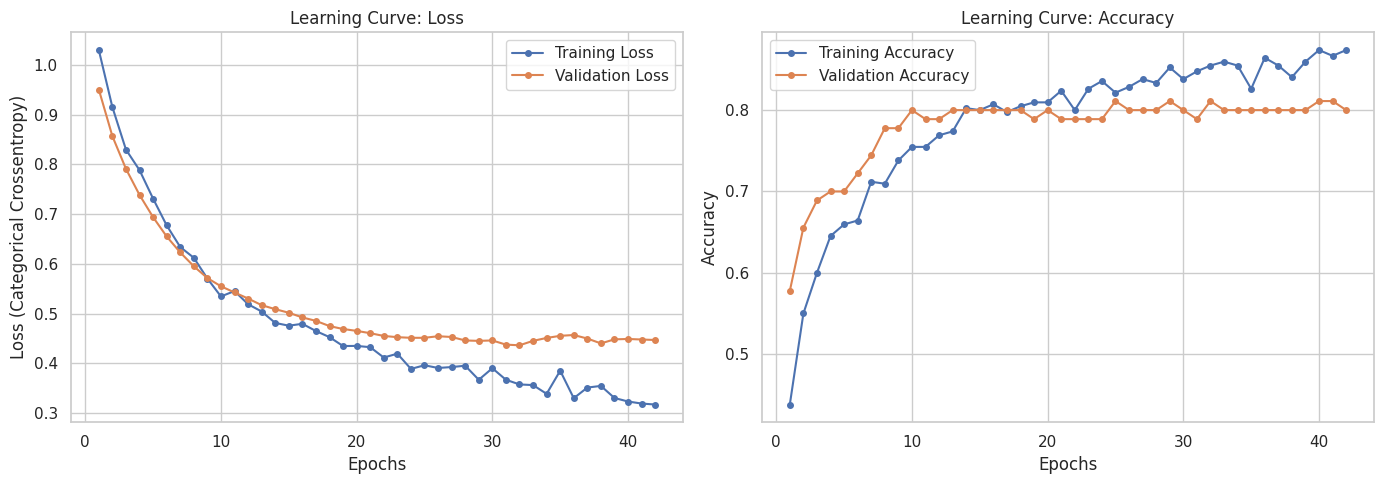

In [18]:
# Extract the data from the training history
train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
epochs_range = range(1, len(train_loss) + 1)

# Create the plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Loss curves
axes[0].plot(epochs_range, train_loss, label='Training Loss', marker='o', markersize=4)
axes[0].plot(epochs_range, val_loss, label='Validation Loss', marker='o', markersize=4)
axes[0].set_title('Learning Curve: Loss')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss (Categorical Crossentropy)')
axes[0].legend()

# Plot 2: Accuracy curves
axes[1].plot(epochs_range, train_acc, label='Training Accuracy', marker='o', markersize=4)
axes[1].plot(epochs_range, val_acc, label='Validation Accuracy', marker='o', markersize=4)
axes[1].set_title('Learning Curve: Accuracy')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

### Step 10: ANN Classification Report & Confusion Matrix
Just like I did for the baseline models, I need to evaluate the ANN's performance across the specific Risk Tiers using Precision, Recall, and the F1-score.

Since Keras outputs probabilities for each class (due to the Softmax layer), I will first need to use `np.argmax` to convert those probabilities into strict class predictions (0, 1, or 2) before passing them to the Scikit-Learn metric functions.

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
ARTIFICIAL NEURAL NETWORK: Validation Performance
              precision    recall  f1-score   support

           0       0.62      0.50      0.56        10
           1       0.72      0.82      0.77        34
           2       0.93      0.87      0.90        46

    accuracy                           0.81        90
   macro avg       0.76      0.73      0.74        90
weighted avg       0.82      0.81      0.81        90



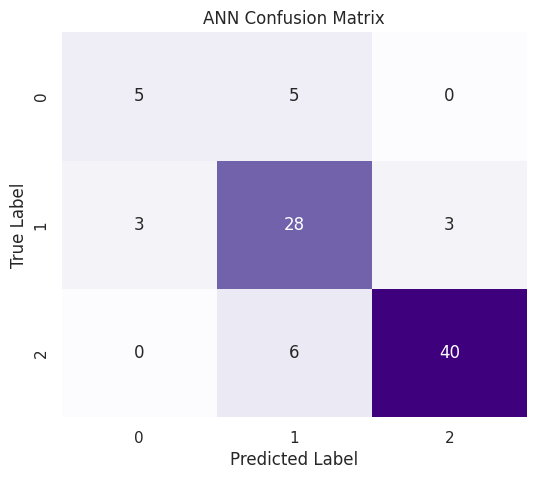

In [19]:
# --- A. Generate Predictions ---
# Predict probabilities
y_val_pred_probs_ann = ann_model.predict(X_val_scaled)

# Convert probabilities to discrete class labels
y_val_pred_ann = np.argmax(y_val_pred_probs_ann, axis=1)

# --- B. Classification Report ---
print("==================================================")
print("ARTIFICIAL NEURAL NETWORK: Validation Performance")
print("==================================================")
print(classification_report(y_val, y_val_pred_ann))

# --- C. Confusion Matrix ---
plt.figure(figsize=(6, 5))
cm_ann = confusion_matrix(y_val, y_val_pred_ann)
sns.heatmap(cm_ann, annot=True, fmt='d', cmap='Purples', cbar=False)
plt.title('ANN Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()